# Creating the Bathymetry
In this notebook, we will create the bathymetry file for the Elkhorn Slough model. 
First, import packages and file paths to re-create and visualize the model grid here:

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

from osgeo import gdal
from scipy.interpolate import griddata

In [4]:
#Insert file paths 

# Source bathymetry raster
file_path = r"C:\Users\rilee\MS 274\Bathy_IC\Elkhorn_Bathy.tif"

# Folder where final MITgcm input files will be saved
input_dir = r"C:\Users\rilee\MS 274\Final_Project\input"

# Final MITgcm bathymetry file name
bathy_output_file = os.path.join(input_dir, "slough_bathymetry.bin")

### Open Bathymetry Raster File 
Next, I will import the source bathymetry tiff file 

In [5]:
src = gdal.Open(file_path)

band = src.GetRasterBand(1)
src_nodata = band.GetNoDataValue()

print("Raster opened successfully")
print("Raster size:", src.RasterXSize, "columns x", src.RasterYSize, "rows")
print("Source no-data value:", src_nodata)
print("Projection:")
print(src.GetProjection())

Raster opened successfully
Raster size: 18443 columns x 17282 rows
Source no-data value: -3.4028230607370965e+38
Projection:
PROJCS["NAD83 / UTM zone 10N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26910"]]


C:\Users\rilee\miniconda3\envs\ms274\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


### Now we will define the model grid from our previous notebook

In [6]:
xgOrigin = -121.795
ygOrigin = 36.8

Nx = 360
Ny = 240

delX = 0.0001555555555555483
delY = 0.00025416666666666643

rxc = xgOrigin + (np.arange(Nx) + 0.5) * delX
ryc = ygOrigin + (np.arange(Ny) + 0.5) * delY

# 2D model grid
rXC, rYC = np.meshgrid(rxc, ryc)

Next, we will warp the raster to our model domain

In [7]:
# Use model grid EDGES for warp bounds
min_lon = xgOrigin
max_lon = xgOrigin + Nx * delX
min_lat = ygOrigin
max_lat = ygOrigin + Ny * delY

# Use a moderate number of pixels for the warped raster
rows, cols = src.RasterYSize, src.RasterXSize
target_px = 8_000_000

stride = int(np.ceil(((rows * cols) / target_px) ** 0.5))
w = max(1, cols // stride)
h = max(1, rows // stride)

warp_kwargs = dict(
    format="VRT",
    dstSRS="EPSG:4326",
    resampleAlg=gdal.GRA_Average,
    outputBounds=(min_lon, min_lat, max_lon, max_lat),
    width=w,
    height=h
)

vrt = gdal.Warp("", src, **warp_kwargs)

Aw = vrt.ReadAsArray().astype(np.float32)
dst_nodata = vrt.GetRasterBand(1).GetNoDataValue()
gtw = vrt.GetGeoTransform()


Some of the raw warped values are invalid (N/A), so we will clean those 

In [8]:
# -----------------------------
# Clean invalid raster values
# -----------------------------

Aw_clean = Aw.astype(np.float32).copy()

# Mask non-finite values
bad = ~np.isfinite(Aw_clean)

# Mask source no-data values if present
if src_nodata is not None:
    bad = bad | np.isclose(Aw_clean, src_nodata)

# Mask destination no-data values if present
if dst_nodata is not None:
    bad = bad | np.isclose(Aw_clean, dst_nodata)

# Mask huge negative no-data values
bad = bad | (Aw_clean < -1e20)

# Replace bad values with NaN for plotting/interpolation
Aw_clean[bad] = np.nan

print("Cleaned warped raster")
print("NaN count:", np.isnan(Aw_clean).sum())
print("Cleaned min:", np.nanmin(Aw_clean))
print("Cleaned max:", np.nanmax(Aw_clean))

Cleaned warped raster
NaN count: 132873
Cleaned min: -29.775415
Cleaned max: 115.97587


Next, we will interpolate the bathymetry onto MITgcm grid

In [9]:
# Coordinates of warped raster cell centers
lonc = gtw[0] + (np.arange(vrt.RasterXSize) + 0.5) * gtw[1]
latc = gtw[3] + (np.arange(vrt.RasterYSize) + 0.5) * gtw[5]

lon2d, lat2d = np.meshgrid(lonc, latc)

# Flatten source points
points = np.column_stack([lon2d.ravel(), lat2d.ravel()])
values = Aw_clean.ravel()

# Only interpolate from valid bathymetry values
valid = np.isfinite(values)

RModel_bathy_raw = griddata(
    points=points[valid],
    values=values[valid],
    xi=(rXC, rYC),
    method="nearest"
)

### Plot Raw Bathymetry and Masks 
Plot the bathymetry file to ensure that the model grid is included, and the elevation has been read in correctly.

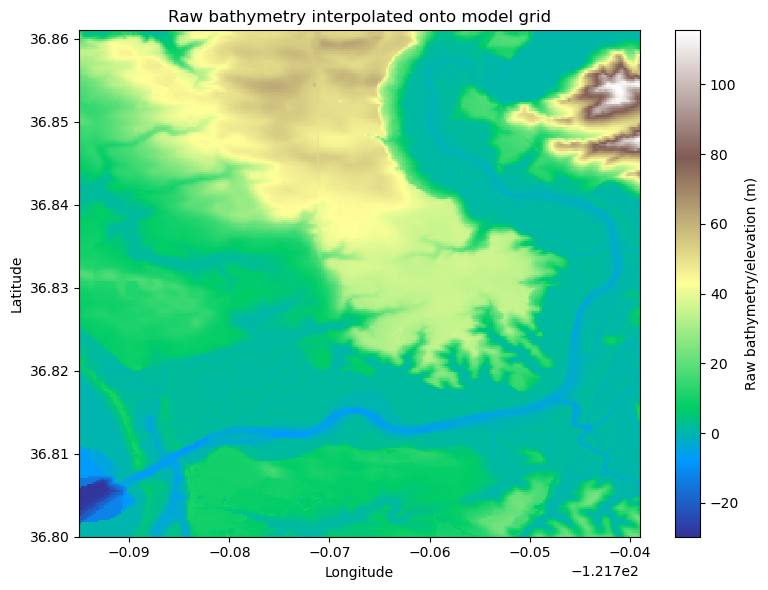

In [10]:
plt.figure(figsize=(8, 6))
im = plt.pcolormesh(
    rXC, rYC, RModel_bathy_raw,
    shading="auto",
    cmap="terrain"
)

plt.colorbar(im, label="Raw bathymetry/elevation (m)")
plt.title("Raw bathymetry interpolated onto model grid")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

### Create MITgcm-ready bathymetry

To create the MITgcm bathymetry, we need to convert any land values to 0, and keep water at negative depths.

In [11]:
mitgcm_bathy = np.where(RModel_bathy_raw < 0, RModel_bathy_raw, 0.0).astype(np.float32)

Now, we because this is a slough where some water areas are disconnected from the main channel, I want to check the wet cells to take out any values that will blow the model. This is to simplfy my model bathymetry for the slough

### Check Wet Cells 

In [12]:
# Check which model edges are wet
wet = mitgcm_bathy < 0

west_edge  = wet[:, 0]
east_edge  = wet[:, -1]
south_edge = wet[0, :]
north_edge = wet[-1, :]

print("Wet cells on west edge:", np.sum(west_edge))
print("Wet cells on east edge:", np.sum(east_edge))
print("Wet cells on south edge:", np.sum(south_edge))
print("Wet cells on north edge:", np.sum(north_edge))

Wet cells on west edge: 77
Wet cells on east edge: 8
Wet cells on south edge: 44
Wet cells on north edge: 0


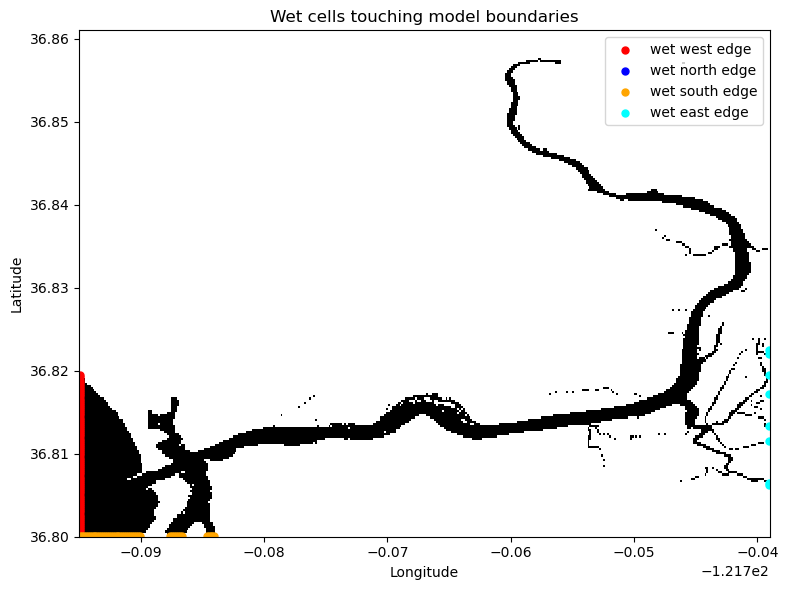

In [13]:
# Visualize wet boundary cells

plt.figure(figsize=(8, 6))

plt.pcolormesh(
    rXC, rYC, wet,
    shading="auto",
    cmap="Greys"
)

# Highlight wet cells on each edge
plt.scatter(rXC[west_edge, 0], rYC[west_edge, 0],
            color="red", s=25, label="wet west edge")

plt.scatter(rXC[-1, north_edge], rYC[-1, north_edge],
            color="blue", s=25, label="wet north edge")

plt.scatter(rXC[0, south_edge], rYC[0, south_edge],
            color="orange", s=25, label="wet south edge")

plt.scatter(rXC[east_edge, -1], rYC[east_edge, -1],
            color="cyan", s=25, label="wet east edge")

plt.title("Wet cells touching model boundaries")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

We want to close the unwanted model boundary edges, as MITgcm will assume these boundaries are touching the ocean. In reality, only the west and southwestern edge have ocean exchange. We will close the edges so that only the west edge has ocean exchangem and the south, east, and north are closed boundaries

In [14]:
mitgcm_bathy_final = mitgcm_bathy.copy()

# Close south boundary
mitgcm_bathy_final[0, :] = 0.0

# Close east boundary
mitgcm_bathy_final[:, -1] = 0.0

# Close north boundary
mitgcm_bathy_final[-1, :] = 0.0

# Important: do NOT close the west boundary

In [15]:
from scipy.ndimage import label

wet = mitgcm_bathy_final < 0

# Label connected wet regions using 4-neighbor connectivity
structure = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

labeled, n_features = label(wet, structure=structure)


# Identify labels that touch the west boundary
west_labels = np.unique(labeled[:, 0])
west_labels = west_labels[west_labels != 0]


# Keep only wet cells connected to the west boundary
connected_to_west = np.isin(labeled, west_labels)

mitgcm_bathy_connected = np.where(
    connected_to_west,
    mitgcm_bathy_final,
    0.0
).astype(np.float32)


In [16]:
# Double check the boundary wet cells after cleanup
wet_connected = mitgcm_bathy_connected < 0

print("Wet west edge:", np.sum(wet_connected[:, 0]))
print("Wet south edge:", np.sum(wet_connected[0, :]))
print("Wet east edge:", np.sum(wet_connected[:, -1]))
print("Wet north edge:", np.sum(wet_connected[-1, :]))

Wet west edge: 76
Wet south edge: 0
Wet east edge: 0
Wet north edge: 0


We can visualize what disconnected wet cells were taken out to ensure that none of the main channel has been removed.

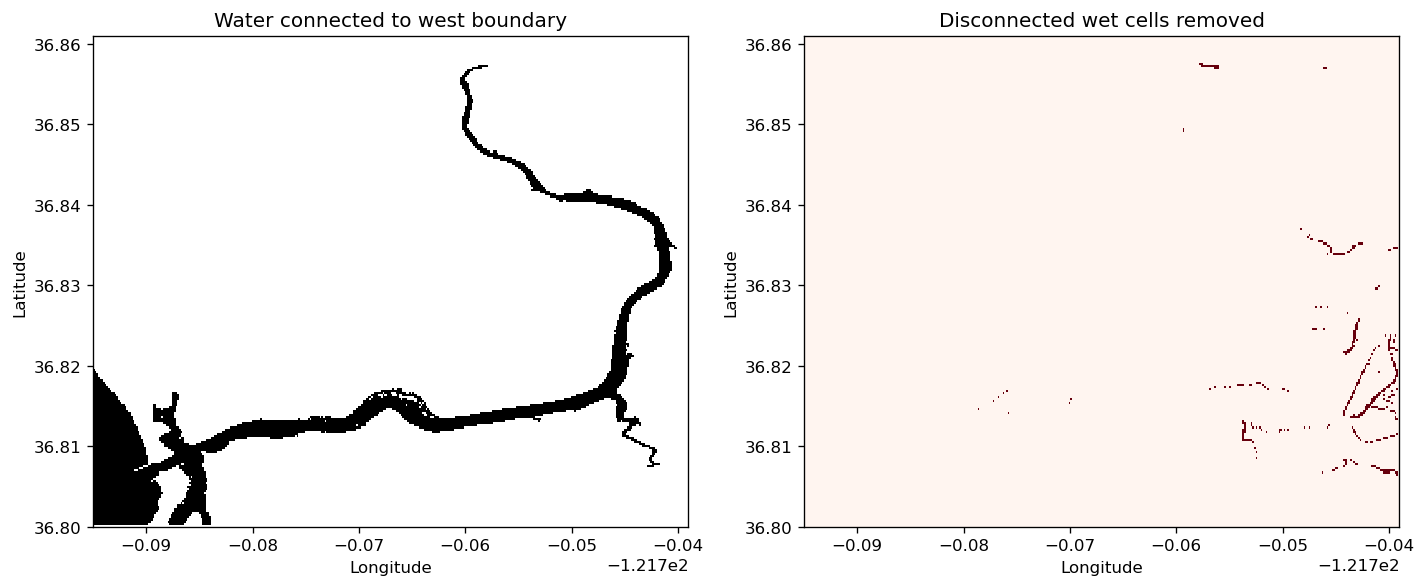

In [17]:
# Plot removed disconnected water patches
removed = (mitgcm_bathy_final < 0) & ~(mitgcm_bathy_connected < 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

axes[0].pcolormesh(rXC, rYC, wet_connected, shading="auto", cmap="Greys")
axes[0].set_title("Water connected to west boundary")

axes[1].pcolormesh(rXC, rYC, removed, shading="auto", cmap="Reds")
axes[1].set_title("Disconnected wet cells removed")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

Finally, we can plot the final MITgcm ready bathymetry

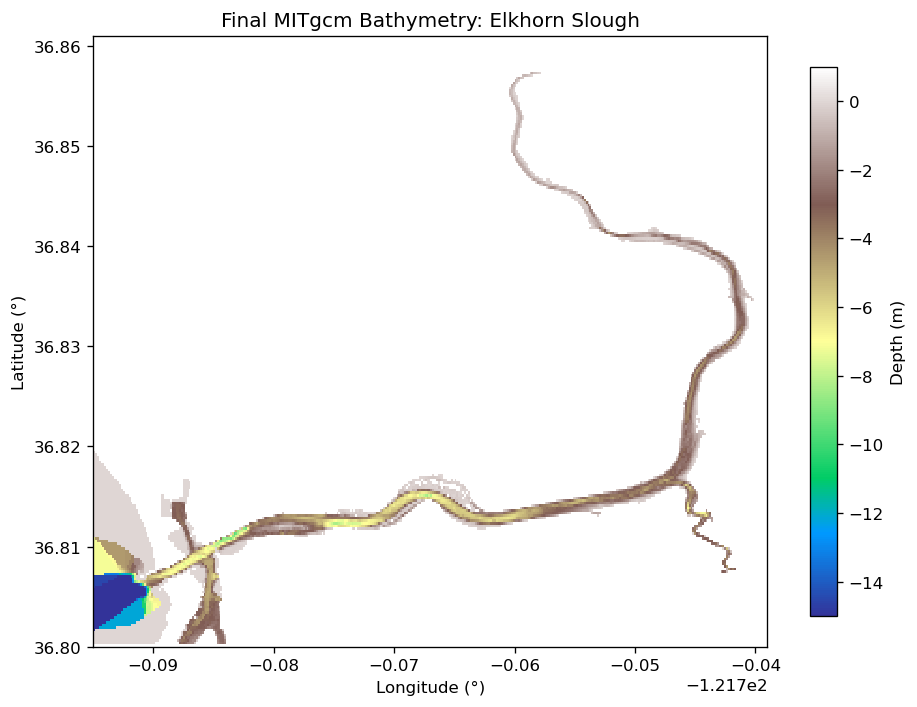

In [18]:
# Mask land cells so they plot as transparent/white
bathy_plot = np.ma.masked_where(mitgcm_bathy_connected == 0, mitgcm_bathy_connected)

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

cmap = plt.get_cmap("terrain").copy()
cmap.set_bad(alpha=0.0)

pcm = ax.pcolormesh(
    rXC,
    rYC,
    bathy_plot,
    vmin=-15,
    vmax=1,
    shading="auto",
    cmap=cmap
)

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.set_label("Depth (m)")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Final MITgcm Bathymetry: Elkhorn Slough")

plt.tight_layout()
plt.show()

### Visualizing the Bathymetry Grid
Finally, Now that the bathymetry has been finalized we can plot and compare with the source data to ensure everything turns out as expected:

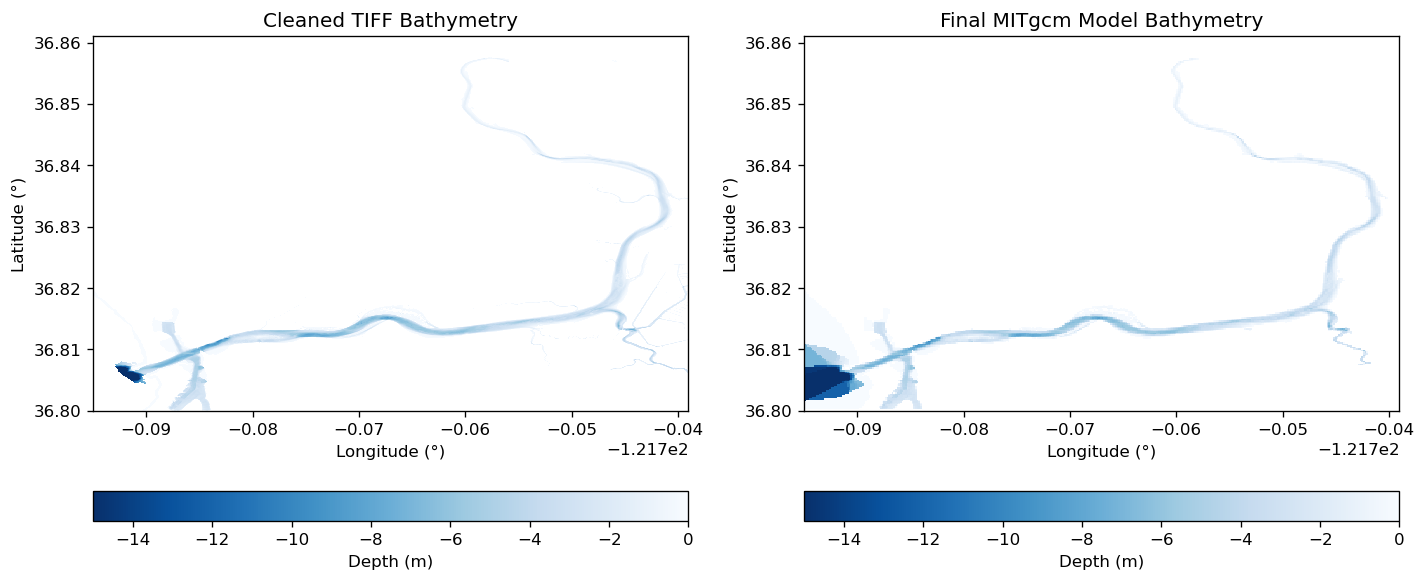

In [19]:
# Mask land/invalid values in the cleaned warped TIFF
Aw_plot = np.ma.masked_where(~np.isfinite(Aw_clean), Aw_clean)
Aw_plot = np.ma.masked_where(Aw_clean >= 0, Aw_plot)

# Mask land in final MITgcm bathymetry
model_bathy_plot = np.ma.masked_where(mitgcm_bathy_connected == 0, mitgcm_bathy_connected)

cmap = plt.get_cmap("Blues_r").copy()
cmap.set_bad("white")

plt.figure(figsize=(12, 5), dpi=120)

plt.subplot(1, 2, 1)
C = plt.pcolormesh(
    lonc,
    latc,
    Aw_plot,
    vmin=-15,
    vmax=0,
    shading="auto",
    cmap=cmap
)
plt.colorbar(C, orientation="horizontal", label="Depth (m)")
plt.title("Cleaned TIFF Bathymetry")
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")

plt.subplot(1, 2, 2)
C = plt.pcolormesh(
    rXC,
    rYC,
    model_bathy_plot,
    vmin=-15,
    vmax=0,
    shading="auto",
    cmap=cmap
)
plt.colorbar(C, orientation="horizontal", label="Depth (m)")
plt.title("Final MITgcm Model Bathymetry")
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")

plt.tight_layout()
plt.show()

### Double check for problem areas and output bathymetry.bin file

The bathymetry model looks good so we can save our new bin file

In [50]:
# Save final MITgcm bathymetry file
output_file = os.path.join(input_dir, "slough_bathymetry.bin")

mitgcm_bathy_connected.ravel(order="C").astype(">f4").tofile(output_file)


Saved: C:\Users\rilee\MS 274\Final_Project\input\slough_bathymetry.bin
Shape: (240, 360)
NaN count: 0
Min: -29.71549
Max: 0.0
Wet cells: 6399
Land cells: 80001
Positive bad cells: 0


This will be implemented into the model by editing the `PARM05` dataset of the `data` file as follows:
```
 &PARM05
 bathyFile = 'slough_bathymetry.bin,
 &
```

The raw interpolated bathymetry includes Monterey Bay water in the southwest corner of the grid. Because the model domain is rectangular, this water initially touched the west, south, and east model boundaries. For this experiment, the western boundary is used to represent ocean exchange with Monterey Bay, while the south, east, and north boundaries are treated as closed. Therefore, wet cells on the south, east, and north edges were set to land while preserving wet cells on the western edge.